# Step 5-6 — Clean BOAMP data and build the M0 source population

Interactive version of `scripts/preprocess_boamp_m0.py` — **running this notebook regenerates the
official pipeline outputs**, with every intermediate result visible inline.

- **Input**: `data/interim/boamp_raw_flattened.csv` (from `scripts/parse_boamp.py`; retrieval and
  parsing stay as scripts since they only talk to the external source).
- **Outputs**: `data/processed/boamp_clean_m0_no_enrichment.csv` (all notice types/sectors, cleaned)
  and `data/processed/boamp_m0_sources.csv` (APPEL_OFFRE, digital scope only).

No external SIREN/SIRET enrichment is performed anywhere. Only BOAMP-provided identifiers are
cleaned/validated (`src/utils/identifiers.py`). The raw data is already restricted to Pays de la
Loire buyers server-side; this step adds the digital/ICT CPV-or-keyword hard filter for the M0
source population only.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from dateutil.relativedelta import relativedelta
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from utils.identifiers import (
    normalize_buyer_name,
    siren_from_siret,
    validate_siren,
    validate_siret,
)
from utils.text_clean import clean_objet, normalize_objet

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## Documented cleaning rules

Tweak these constants and re-run to see how the source population reacts. The digital scope is a
CPV-or-keyword filter because CPV coverage among APPEL_OFFRE sources is too low (~39% nationally)
for a CPV-only rule; the CPV-only count is still reported as a sensitivity check.

In [2]:
MAX_PLAUSIBLE_DURATION_MONTHS = 120  # 10 years; longer values are treated as OUT_OF_RANGE
MIN_PLAUSIBLE_DURATION_MONTHS = 1

# Digital/ICT scope: HARD FILTER on the M0 source population (Step 5-I) -
# CPV divisions 48 (software), 72 (IT services), 32 (telecom), 35 (security),
# OR a digital keyword hit in the cleaned object text.
DIGITAL_CPV_DIVISIONS = {"32", "35", "48", "72"}
DIGITAL_KEYWORDS = [
    "informatique", "logiciel", "numerique", "num\u00e9rique", "cloud", "cybersecurite",
    "cybers\u00e9curit\u00e9", "reseau informatique", "r\u00e9seau informatique", "application web",
    "systeme d'information", "syst\u00e8me d'information", "site internet", "infogerance",
    "infog\u00e9rance", "erp", "progiciel", "developpement logiciel", "d\u00e9veloppement logiciel",
]

# Pays de la Loire departments - defense-in-depth diagnostic only (the
# download-time filter already restricts to these).
PDL_DEPARTMENTS = {"44", "49", "53", "72", "85"}


def normalize_notice_type(nature_raw: str) -> str:
    if not isinstance(nature_raw, str) or not nature_raw.strip():
        return "OTHER"
    v = nature_raw.strip().upper()
    if v == "APPEL_OFFRE":
        return "APPEL_OFFRE"
    if v == "ATTRIBUTION":
        return "ATTRIBUTION"
    return "OTHER"


def first_token(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return None
    s = str(value)
    if not s or s.lower() == "nan":
        return None
    return s.split(";")[0].strip() or None


def cpv_is_generic(cpv_main: str) -> bool:
    # 'generic' = only the 2-digit division is meaningful (pattern XX000000):
    # the notice classified itself at the broadest possible level.
    if not cpv_main or len(cpv_main) != 8:
        return False
    return cpv_main[2:] == "000000"


def tag_digital_scope(cpv_division, objet_normalized) -> bool:
    if cpv_division in DIGITAL_CPV_DIVISIONS:
        return True
    if isinstance(objet_normalized, str):
        for kw in DIGITAL_KEYWORDS:
            if kw in objet_normalized:
                return True
    return False

## Load the flattened interim data

In [3]:
# dtype=str for everything on read: several columns (CPV/SIRET/SIREN candidate
# strings) are numeric-looking with NaNs, which pandas would otherwise silently
# coerce to float64 and break later `.str[...]` slicing.
df = pd.read_csv(INTERIM_DIR / "boamp_raw_flattened.csv", low_memory=False, dtype=str)
df["duration_months_raw"] = pd.to_numeric(df["duration_months_raw"], errors="coerce")
print(f"Loaded {len(df)} rows, {df.shape[1]} columns")
display(df.head(3))

Loaded 84623 rows, 42 columns


,idweb,id,objet,filename,famille,famille_libelle,code_departement,code_departement_prestation,dateparution,datefindiffusion,...,etat,schema_family,siret_candidates_raw,siren_candidates_raw,cpv_candidates_raw,duration_months_raw,duration_source_key,notice_id_raw,source_file,raw_record_hash
0,15-28783,15_28783,fourniture de café avec mise à disposition des...,BOAMP-J-AO_2015_062009,JOUE,Marchés européens,44,44,2015-03-03,2015-04-13,...,INITIAL,LEGACY,NaN,NaN,15861000,NaN,NaN,15-28783,boamp_201503.json,4fc4faf047968d0862bb6d966fbdf61c6b20178131b110...
1,15-31324,15_31324,Prestation d'assurance pour les besoins de la ...,BOAMP-J-AO_2015_062009,JOUE,Marchés européens,44;85;72;79,44,2015-03-03,2015-04-13,...,INITIAL,LEGACY,NaN,NaN,66515200;66516000;66514110;66512000;66513100,NaN,NaN,15-31324,boamp_201503.json,2c963ba9c2f72b06cf5e6e50bd09f534801b5dd089c46c...
2,15-32027,15_32027,mise en service de vélos neufs classiques et p...,BOAMP-J-AO_2015_063003,JOUE,Marchés européens,49,49,2015-03-03,2015-04-14,...,INITIAL,LEGACY,NaN,NaN,50000000,NaN,NaN,15-32027,boamp_201503.json,c6fbb9bb34f9987efcba94b3673f2dd9e2778e450ec4ad...


## A-B. Notice ID and notice type

In [4]:
df["notice_id"] = df["notice_id_raw"]
dupe_ids = df["notice_id"].duplicated().sum()
if dupe_ids:
    print(f"WARNING: {dupe_ids} duplicate notice_id values found; keeping first occurrence")
    df = df.drop_duplicates(subset="notice_id", keep="first")

df["notice_type_raw"] = df["nature"]
df["notice_type_normalized"] = df["nature"].map(normalize_notice_type)
display(df["notice_type_normalized"].value_counts().rename("notices"))

notice_type_normalized
APPEL_OFFRE    58292
ATTRIBUTION    22560
OTHER           3771
Name: notices, dtype: int64

## C. Dates

In [5]:
df["publication_date"] = pd.to_datetime(df["dateparution"], errors="coerce", utc=True).dt.tz_localize(None)
df["publication_year"] = df["publication_date"].dt.year
df["publication_month"] = df["publication_date"].dt.month
df["publication_quarter"] = df["publication_date"].dt.quarter
df["end_diffusion_date"] = pd.to_datetime(df["datefindiffusion"], errors="coerce", utc=True).dt.tz_localize(None)
df["response_deadline"] = pd.to_datetime(df["datelimitereponse"], errors="coerce", utc=True).dt.tz_localize(None)
print(f"publication_date range: {df['publication_date'].min()} -> {df['publication_date'].max()}")
print(f"missing publication_date: {df['publication_date'].isna().sum()}")

publication_date range: 2015-03-02 00:00:00 -> 2026-07-13 00:00:00
missing publication_date: 0


## D. Buyer identity (no external enrichment)

SIRET/SIREN are validated (format + Luhn checksum) but never looked up externally. The buyer key
falls back from SIRET to SIREN to normalized name.

In [6]:
df["buyer_name_raw"] = df["nomacheteur"]
df["buyer_name_normalized"] = df["buyer_name_raw"].map(normalize_buyer_name)

df["buyer_siret_raw"] = df["siret_candidates_raw"].map(first_token)
siret_checks = df["buyer_siret_raw"].map(validate_siret)
df["buyer_siret_format_valid"] = siret_checks.map(lambda t: t[0])
df["buyer_siret_checksum_valid"] = siret_checks.map(lambda t: t[1])
df["buyer_siret_clean"] = np.where(df["buyer_siret_format_valid"], df["buyer_siret_raw"], None)

df["buyer_siren_raw"] = df["siren_candidates_raw"].map(first_token)
siren_checks = df["buyer_siren_raw"].map(validate_siren)
df["buyer_siren_format_valid"] = siren_checks.map(lambda t: t[0])
df["buyer_siren_checksum_valid"] = siren_checks.map(lambda t: t[1])
df["buyer_siren_clean"] = np.where(df["buyer_siren_format_valid"], df["buyer_siren_raw"], None)

derived_mask = df["buyer_siren_clean"].isna() & df["buyer_siret_clean"].notna()
df.loc[derived_mask, "buyer_siren_clean"] = df.loc[derived_mask, "buyer_siret_clean"].map(siren_from_siret)


def identifier_source(row):
    if pd.notna(row["buyer_siret_clean"]):
        return "RAW_SIRET_FIELD"
    if pd.notna(row["buyer_siren_raw"]) and pd.notna(row["buyer_siren_clean"]) and not derived_mask.get(row.name, False):
        return "RAW_SIREN_FIELD"
    if pd.notna(row["buyer_siren_clean"]):
        return "DERIVED_FROM_SIRET"
    return "NONE"


df["buyer_identifier_source"] = df.apply(identifier_source, axis=1)


def buyer_key_and_type(row):
    if pd.notna(row["buyer_siret_clean"]):
        return f"SIRET:{row['buyer_siret_clean']}", "RAW_SIRET"
    if pd.notna(row["buyer_siren_clean"]):
        return f"SIREN:{row['buyer_siren_clean']}", "RAW_SIREN"
    if pd.notna(row["buyer_name_normalized"]):
        return f"NAME:{row['buyer_name_normalized']}", "NAME_FALLBACK"
    return None, "MISSING"


keys_types = df.apply(buyer_key_and_type, axis=1)
df["buyer_key"] = keys_types.map(lambda t: t[0])
df["buyer_key_type"] = keys_types.map(lambda t: t[1])

display(pd.concat([
    df["buyer_identifier_source"].value_counts().rename("identifier_source"),
    df["buyer_key_type"].value_counts().rename("buyer_key_type"),
], axis=1))

,identifier_source,buyer_key_type
NONE,61585.0,NaN
RAW_SIRET_FIELD,23038.0,NaN
NAME_FALLBACK,NaN,61585.0
RAW_SIRET,NaN,23038.0


## E-F. Text and CPV fields

In [7]:
df["objet_raw"] = df["objet"]
df["objet_clean"] = df["objet_raw"].map(clean_objet)
df["objet_normalized"] = df["objet_clean"].map(normalize_objet)
df["text_length"] = df["objet_clean"].fillna("").map(len)
df["token_count"] = df["objet_clean"].fillna("").map(lambda s: len(s.split()))
df["object_missing_flag"] = df["objet_clean"].isna()

df["cpv_raw"] = df["cpv_candidates_raw"]
df["cpv_clean"] = df["cpv_candidates_raw"].map(first_token)
df.loc[~df["cpv_clean"].fillna("").str.fullmatch(r"\d{8}"), "cpv_clean"] = None
df["cpv_main"] = df["cpv_clean"]
df["cpv_division"] = df["cpv_main"].str[0:2]
df["cpv_group"] = df["cpv_main"].str[0:3]
df["cpv_class"] = df["cpv_main"].str[0:4]
df["cpv_category"] = df["cpv_main"].str[0:5]
df["cpv_missing"] = df["cpv_main"].isna()
df["cpv_generic_flag"] = df["cpv_main"].map(lambda v: cpv_is_generic(v) if pd.notna(v) else False)

print(f"text missing: {df['object_missing_flag'].mean():.2%}")
print(f"CPV coverage (all notices): {1 - df['cpv_missing'].mean():.2%}")
print(f"generic CPV share (among coded): {df.loc[~df['cpv_missing'], 'cpv_generic_flag'].mean():.2%}")

text missing: 0.00%
CPV coverage (all notices): 70.32%
generic CPV share (among coded): 7.06%


## Scope tagging (digital/ICT + Pays-de-la-Loire diagnostic)

In [8]:
df["is_digital_scope"] = df.apply(lambda r: tag_digital_scope(r["cpv_division"], r["objet_normalized"]), axis=1)
df["category_label"] = np.where(df["is_digital_scope"], "DIGITAL_ICT", "OTHER")
df["is_digital_scope_cpv_only"] = df["cpv_division"].isin(DIGITAL_CPV_DIVISIONS)

df["_dept_tokens"] = df["code_departement"].fillna("").astype(str).str.split(";")
df["is_in_pdl"] = df["_dept_tokens"].map(lambda toks: any(t.strip() in PDL_DEPARTMENTS for t in toks))
n_outside_pdl = int((~df["is_in_pdl"]).sum())
if n_outside_pdl:
    print(f"WARNING: {n_outside_pdl} cleaned notices have no department in {sorted(PDL_DEPARTMENTS)} - "
          f"expected ~0 given the download-time filter (kept, not dropped).")
df = df.drop(columns=["_dept_tokens"])

print(f"digital scope (CPV-or-keyword): {df['is_digital_scope'].sum()} notices")
print(f"digital scope (CPV-division only, sensitivity): {df['is_digital_scope_cpv_only'].sum()} notices")

digital scope (CPV-or-keyword): 4830 notices
digital scope (CPV-division only, sensitivity): 3017 notices


## G. Durations + documented median imputation

Missing durations on in-scope APPEL_OFFRE notices are imputed with the median observed duration in
the same CPV division (global median fallback), computed on the digital + PdL source scope only.

In [9]:
df["duration_raw"] = df["duration_months_raw"]
in_range = df["duration_raw"].between(MIN_PLAUSIBLE_DURATION_MONTHS, MAX_PLAUSIBLE_DURATION_MONTHS)
df["declared_duration_months"] = np.where(df["duration_raw"].notna() & in_range, df["duration_raw"], np.nan)
df["duration_unit"] = np.where(df["declared_duration_months"].notna(), "months", None)
df["duration_valid"] = df["declared_duration_months"].notna()
df["duration_quality_flag"] = np.select(
    [
        df["declared_duration_months"].notna(),
        df["duration_raw"].notna() & ~in_range,
    ],
    ["OBSERVED", "OUT_OF_RANGE"],
    default="MISSING",
)
df["dur_was_imputed"] = False

ao_mask = (df["notice_type_normalized"] == "APPEL_OFFRE") & df["is_digital_scope"]
global_median = df.loc[ao_mask & df["duration_valid"], "declared_duration_months"].median()
div_medians = (
    df.loc[ao_mask & df["duration_valid"]]
    .groupby("cpv_division")["declared_duration_months"]
    .median()
)
needs_impute = ao_mask & ~df["duration_valid"]
imputed_vals = df.loc[needs_impute, "cpv_division"].map(div_medians).fillna(global_median)
df.loc[needs_impute, "declared_duration_months"] = imputed_vals
df.loc[needs_impute, "dur_was_imputed"] = True
df.loc[needs_impute & df["declared_duration_months"].notna(), "duration_quality_flag"] = "IMPUTED_MEDIAN_BY_CPV_DIVISION"
still_missing = needs_impute & df["declared_duration_months"].isna()
if still_missing.any():
    df.loc[still_missing, "declared_duration_months"] = global_median
    df.loc[still_missing, "dur_was_imputed"] = True
    df.loc[still_missing, "duration_quality_flag"] = "IMPUTED_MEDIAN_GLOBAL"

print(f"Global median observed APPEL_OFFRE duration (months): {global_median}")
display(div_medians.rename("median_duration_months_by_cpv_division"))
display(df.loc[ao_mask, "duration_quality_flag"].value_counts().rename("in-scope APPEL_OFFRE"))

Global median observed APPEL_OFFRE duration (months): 6.0


cpv_division
30    24.0
32    36.0
34    36.0
35    48.0
38    12.0
39    18.0
42     8.0
45    12.0
48    48.0
50    36.0
66    30.0
71    36.0
72    48.0
79    48.0
80    12.0
90    36.0
92    13.0
Name: median_duration_months_by_cpv_division, dtype: float64

duration_quality_flag
IMPUTED_MEDIAN_BY_CPV_DIVISION    2781
OBSERVED                           378
Name: in-scope APPEL_OFFRE, dtype: int64

## H. Start date via ATTRIBUTION reverse-lookup

For each APPEL_OFFRE, find ATTRIBUTION notices whose `annonce_lie` references it (BOAMP-native
linkage only). Earliest linked attribution date wins; publication date is the fallback.

In [10]:
attribution_links = {}
attr_rows = df.loc[df["notice_type_normalized"] == "ATTRIBUTION", ["notice_id", "annonce_lie", "publication_date"]]
for _, r in attr_rows.iterrows():
    if pd.isna(r["annonce_lie"]):
        continue
    for ref in str(r["annonce_lie"]).split(";"):
        ref = ref.strip()
        if ref:
            if ref not in attribution_links or r["publication_date"] < attribution_links[ref][1]:
                attribution_links[ref] = (r["notice_id"], r["publication_date"])

df["linked_attribution_notice_id"] = df["notice_id"].map(lambda i: attribution_links.get(i, (None, None))[0])
df["linked_attribution_date"] = df["notice_id"].map(lambda i: attribution_links.get(i, (None, None))[1])

start_date = df["linked_attribution_date"].where(df["linked_attribution_date"].notna(), df["publication_date"])
start_source = np.where(df["linked_attribution_date"].notna(), "LINKED_ATTRIBUTION_DATE", "PUBLICATION_DATE_FALLBACK")
df["start_date"] = start_date
df["start_date_source"] = start_source

display(df.loc[df["notice_type_normalized"] == "APPEL_OFFRE", "start_date_source"]
        .value_counts(normalize=True).rename("share of APPEL_OFFRE"))

start_date_source
PUBLICATION_DATE_FALLBACK    0.678755
LINKED_ATTRIBUTION_DATE      0.321245
Name: share of APPEL_OFFRE, dtype: float64

## Write the full cleaned dataset (all notice types/sectors)

In [11]:
clean_path = PROCESSED_DIR / "boamp_clean_m0_no_enrichment.csv"
df.to_csv(clean_path, index=False)
print(f"Wrote cleaned dataset -> {clean_path} ({len(df)} rows)")

Wrote cleaned dataset -> /home/senghakrou/survival-analysis/data/processed/boamp_clean_m0_no_enrichment.csv (84623 rows)


## Step 6 — M0 source population (APPEL_OFFRE, digital scope only)

The digital/ICT filter is a hard filter here; the full cleaned dataset above keeps everything (the
ATTRIBUTION reverse-lookup needs the full population regardless of theme).

In [12]:
study_end_date = df["publication_date"].max()
appel_offre_all = df.loc[df["notice_type_normalized"] == "APPEL_OFFRE"]
n_appel_offre_all = len(appel_offre_all)
n_digital_cpv_only = int((appel_offre_all["is_digital_scope_cpv_only"]).sum())
sources = appel_offre_all.loc[appel_offre_all["is_digital_scope"]].copy()
print(f"APPEL_OFFRE total (all sectors): {n_appel_offre_all}")
print(f"APPEL_OFFRE digital scope (CPV-or-keyword, used as M0 sources): {len(sources)}")
print(f"APPEL_OFFRE digital scope (CPV-division-only, sensitivity check): {n_digital_cpv_only}")

sources["estimated_end_date"] = sources.apply(
    lambda r: (r["start_date"] + relativedelta(months=int(round(r["declared_duration_months"]))))
    if pd.notna(r["start_date"]) and pd.notna(r["declared_duration_months"]) else pd.NaT,
    axis=1,
)
sources["study_end_date"] = study_end_date

m0_cols = [
    "notice_id", "publication_date", "start_date", "start_date_source",
    "buyer_key", "buyer_key_type", "buyer_name_normalized",
    "buyer_siret_clean", "buyer_siren_clean",
    "objet_clean", "cpv_clean", "cpv_division", "cpv_group", "cpv_class", "cpv_category", "cpv_generic_flag",
    "declared_duration_months", "dur_was_imputed", "estimated_end_date",
    "is_digital_scope", "category_label", "study_end_date",
]
sources_out = sources[m0_cols]
sources_path = PROCESSED_DIR / "boamp_m0_sources.csv"
sources_out.to_csv(sources_path, index=False)
print(f"Wrote M0 source population -> {sources_path} ({len(sources_out)} rows)")
print(f"Study end date (max publication_date observed): {study_end_date}")
display(sources_out.head(3))

APPEL_OFFRE total (all sectors): 58292
APPEL_OFFRE digital scope (CPV-or-keyword, used as M0 sources): 3159
APPEL_OFFRE digital scope (CPV-division-only, sensitivity check): 1882
Wrote M0 source population -> /home/senghakrou/survival-analysis/data/processed/boamp_m0_sources.csv (3159 rows)
Study end date (max publication_date observed): 2026-07-13 00:00:00


,notice_id,publication_date,start_date,start_date_source,buyer_key,buyer_key_type,buyer_name_normalized,buyer_siret_clean,buyer_siren_clean,objet_clean,...,cpv_group,cpv_class,cpv_category,cpv_generic_flag,declared_duration_months,dur_was_imputed,estimated_end_date,is_digital_scope,category_label,study_end_date
12,15-46309,2015-03-26,2015-07-29,LINKED_ATTRIBUTION_DATE,SIRET:22720002900014,RAW_SIRET,conseil general de la sarthe,22720002900014,227200029,travaux de création graphique pour les besoins...,...,325,3258,32584,False,36.0,True,2018-07-29,True,DIGITAL_ICT,2026-07-13
62,15-39486,2015-03-16,2015-03-16,PUBLICATION_DATE_FALLBACK,NAME:altantic eau,NAME_FALLBACK,altantic eau,None,None,Maintenance du parc informatique,...,None,None,None,False,6.0,True,2015-09-16,True,DIGITAL_ICT,2026-07-13
83,15-30947,2015-03-02,2015-03-02,PUBLICATION_DATE_FALLBACK,NAME:smictom de la vallee de l authion,NAME_FALLBACK,smictom de la vallee de l authion,None,None,Acquisition de systèmes d'identification embar...,...,480,4800,48000,True,48.0,True,2019-03-02,True,DIGITAL_ICT,2026-07-13


## Diagnostics & figures

Same charts (and filenames) as `scripts/make_figures.py`, figures 01-05, now rendered inline.

In [13]:
import matplotlib.pyplot as plt

# Palette tokens (light mode) - the project's validated dataviz reference palette,
# identical to scripts/make_figures.py so notebook and script output match.
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

CAT = {
    "blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100", "green": "#008300",
    "violet": "#4a3aa7", "red": "#e34948", "magenta": "#e87ba4", "orange": "#eb6834",
}

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_PRIMARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY,
    "ytick.color": INK_SECONDARY,
    "axes.grid": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
})

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_and_show(fig, name):
    """Save under reports/figures (same filenames as the figure scripts) and display inline."""
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200)
    plt.show()


def bar_by_year(series, title, ylabel, name, color=CAT["blue"]):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(series.index.astype(str), series.values, color=color, width=0.62, edgecolor="none")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Publication year")
    ax.grid(axis="x")
    ax.spines["left"].set_color(BASELINE)
    save_and_show(fig, name)

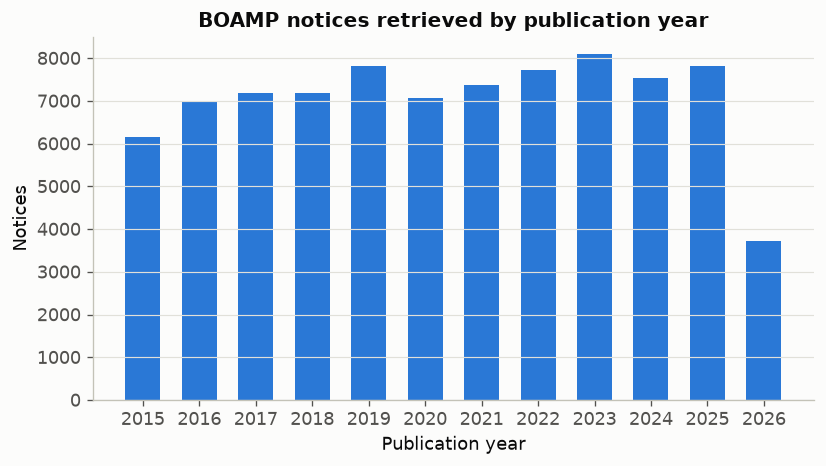

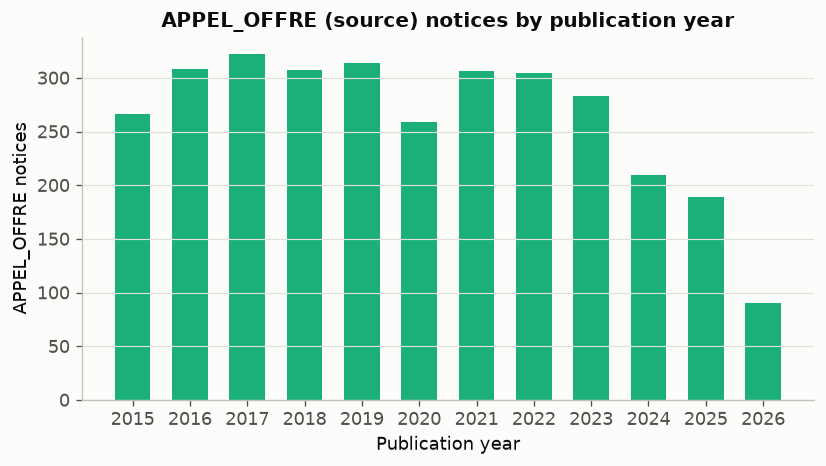

In [14]:
bar_by_year(df.groupby("publication_year").size(),
            "BOAMP notices retrieved by publication year",
            "Notices", "01_notice_count_by_year", color=CAT["blue"])

src_year = sources["publication_date"].dt.year
bar_by_year(sources.groupby(src_year).size(),
            "APPEL_OFFRE (source) notices by publication year",
            "APPEL_OFFRE notices", "02_appel_offre_count_by_year", color=CAT["aqua"])

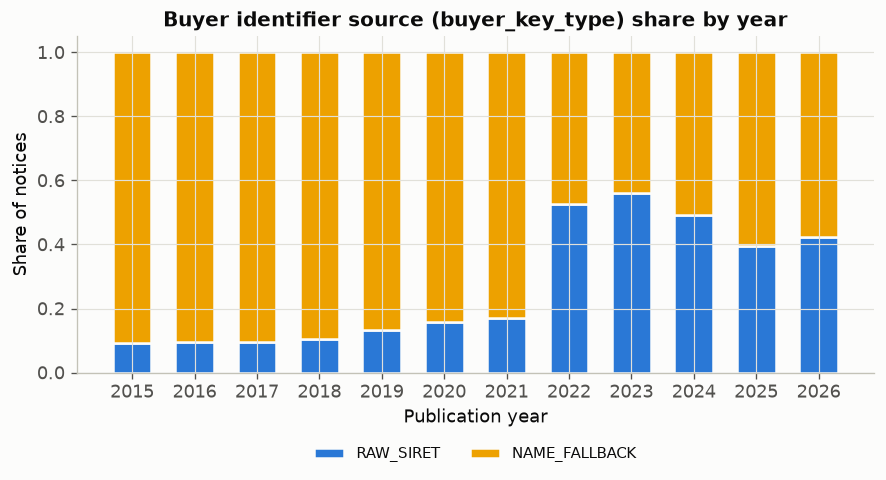

In [15]:
bkt = (df.groupby(["publication_year", "buyer_key_type"]).size().unstack(fill_value=0))
bkt_share = bkt.div(bkt.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bottom = pd.Series(0.0, index=bkt_share.index)
key_types = ["RAW_SIRET", "RAW_SIREN", "NAME_FALLBACK", "MISSING"]
colors = [CAT["blue"], CAT["aqua"], CAT["yellow"], INK_MUTED]
for kt, col in zip(key_types, colors):
    if kt not in bkt_share.columns:
        continue
    ax.bar(bkt_share.index.astype(str), bkt_share[kt], bottom=bottom, label=kt,
           color=col, width=0.62, edgecolor=SURFACE, linewidth=1.5)
    bottom += bkt_share[kt]
ax.set_title("Buyer identifier source (buyer_key_type) share by year")
ax.set_ylabel("Share of notices")
ax.set_xlabel("Publication year")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, fontsize=9)
save_and_show(fig, "03_buyer_key_type_by_year")

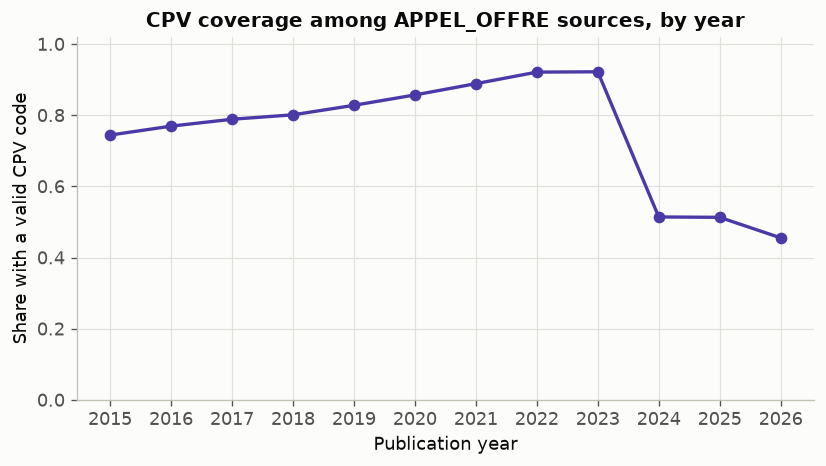

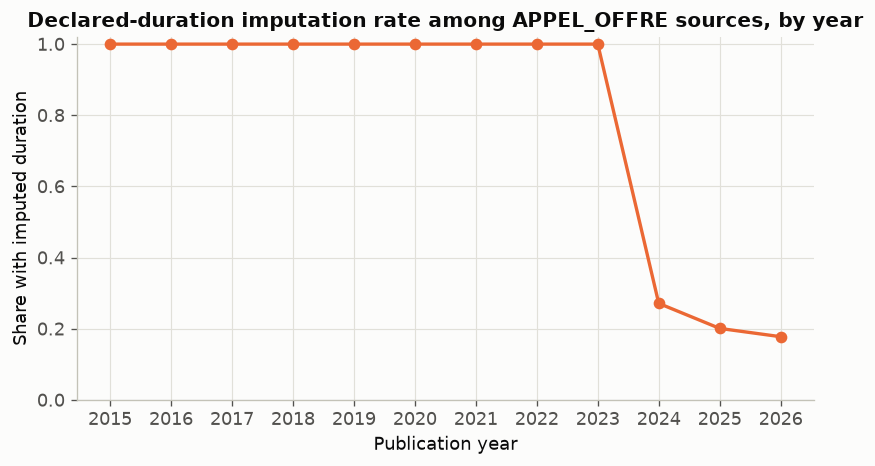

In [16]:
cpv_cov = sources.groupby(src_year).apply(lambda g: 1 - g["cpv_clean"].isna().mean())
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cpv_cov.index.astype(str), cpv_cov.values, marker="o", color=CAT["violet"], linewidth=2, markersize=6)
ax.set_ylim(0, 1.02)
ax.set_title("CPV coverage among APPEL_OFFRE sources, by year")
ax.set_ylabel("Share with a valid CPV code")
ax.set_xlabel("Publication year")
save_and_show(fig, "04_cpv_coverage_by_year")

dur_missing = sources.groupby(src_year).apply(lambda g: g["dur_was_imputed"].mean())
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dur_missing.index.astype(str), dur_missing.values, marker="o", color=CAT["orange"], linewidth=2, markersize=6)
ax.set_ylim(0, 1.02)
ax.set_title("Declared-duration imputation rate among APPEL_OFFRE sources, by year")
ax.set_ylabel("Share with imputed duration")
ax.set_xlabel("Publication year")
save_and_show(fig, "05_duration_missingness_by_year")